# Russell 2000 Rebalance: CAR by Sub-Period

Splits three key groups into four ~5-year windows to test whether pre-positioning and post-rank drift are persistent or concentrated in a specific era.

**Groups:** ADD: FROM RMICRO · DELETE: TO RMICRO · ADD: FROM R1000

**Periods:** 2006–2010 · 2011–2015 · 2016–2020 · 2021–2025

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pyarrow.parquet as pq
from pathlib import Path

sns.set_theme(style='whitegrid', font_scale=1.1)
PROCESSED_DIR  = Path('../data/processed')
RAW_PRICES_DIR = Path('../data/raw/prices')

## 1. Parquet & Price Columns

In [2]:
PARQUET_PATH = PROCESSED_DIR / 'FINALIZED_PRICES.parquet'

if not PARQUET_PATH.exists():
    print('Converting CSV → Parquet (one-time, ~30s)...')
    _prices = pd.read_csv(
        RAW_PRICES_DIR / 'FINALIZED_PRICES_CSV.csv',
        index_col=0, parse_dates=True,
        na_values=['#N/A N/A', '#N/A', 'N/A', '#NA'],
        encoding='utf-8-sig'
    )
    _prices.index = pd.to_datetime(_prices.index)
    _prices = _prices.apply(pd.to_numeric, errors='coerce')
    _prices.sort_index().to_parquet(PARQUET_PATH)
    del _prices
    print(f'Saved → {PARQUET_PATH}')
else:
    print(f'Parquet exists ({PARQUET_PATH.stat().st_size / 1e6:.1f} MB)')

PRICE_COLS = set(pq.read_schema(PARQUET_PATH).names)
print(f'Tickers in Parquet: {len(PRICE_COLS):,}')

Parquet exists (124.1 MB)
Tickers in Parquet: 11,546


## 2. Fama-French 5 Factors

In [3]:
FF5 = pd.read_csv(
    PROCESSED_DIR / 'F-F_Research_Data_5_Factors_2x3_daily.csv',
    skiprows=2, header=None,
    names=['Date', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
)
FF5['Date'] = pd.to_datetime(FF5['Date'].astype(str), format='%Y%m%d')
FF5 = FF5.set_index('Date') / 100

FACTOR_COLS = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']
print(f'FF5: {FF5.shape[0]:,} days  |  {FF5.index.min().date()} → {FF5.index.max().date()}')

FF5: 15,666 days  |  1963-07-02 → 2025-09-30


## 3. Events

In [4]:
events = pd.read_csv(str(PROCESSED_DIR / 'russell_events.csv'))
events['Rank_Date'] = pd.to_datetime(events['Rank_Date'])

print(f'Events: {len(events):,} rows  |  {events["Rank_Date"].dt.year.min()}–{events["Rank_Date"].dt.year.max()}')
print(events['Classification'].value_counts())

Events: 7,517 rows  |  2006–2025
Classification
TO_RMICRO      2983
FROM_RMICRO    2251
FROM_R1000     1631
TO_R1000        652
Name: count, dtype: int64


## 4. Event Study Parameters & Function

In [5]:
EST_START   = -250
EST_END     = -81
EVT_START   = -80
EVT_END     = 20
MIN_EST_OBS = 120
EVENT_DAYS  = list(range(EVT_START, EVT_END + 1))


def run_event_study(events_subset: pd.DataFrame) -> pd.DataFrame:
    needed  = [t for t in events_subset['Ticker'].unique() if t in PRICE_COLS]
    if not needed:
        print('  No tickers found in Parquet.')
        return pd.DataFrame(columns=EVENT_DAYS)

    prices_grp  = pd.read_parquet(PARQUET_PATH, columns=needed)
    returns_grp = prices_grp.pct_change(fill_method=None)
    returns_grp = returns_grp[returns_grp.index.isin(FF5.index)]

    car_paths = []
    n_no_ticker = n_short = n_est_fail = n_evt_gap = 0

    for _, row in events_subset.iterrows():
        tkr, rank_date = row['Ticker'], row['Rank_Date']

        if tkr not in returns_grp.columns:
            n_no_ticker += 1; continue

        tkr_ret = returns_grp[tkr].dropna()
        if len(tkr_ret) == 0:
            n_no_ticker += 1; continue

        rank_idx = tkr_ret.index.searchsorted(rank_date)
        est_s = rank_idx + EST_START; est_e = rank_idx + EST_END + 1
        evt_s = rank_idx + EVT_START; evt_e = rank_idx + EVT_END + 1

        if est_s < 0 or evt_e > len(tkr_ret):
            n_short += 1; continue

        est_dates = tkr_ret.index[est_s:est_e]
        evt_dates = tkr_ret.index[evt_s:evt_e]

        if len(evt_dates) != len(EVENT_DAYS):
            n_short += 1; continue

        est_ff5    = FF5.reindex(est_dates)[FACTOR_COLS + ['RF']].dropna()
        common_est = tkr_ret.index.intersection(est_ff5.index)

        if len(common_est) < MIN_EST_OBS:
            n_est_fail += 1; continue

        est_excess = tkr_ret.loc[common_est] - FF5.loc[common_est, 'RF']
        X_est      = sm.add_constant(FF5.loc[common_est, FACTOR_COLS])
        try:
            model = sm.OLS(est_excess, X_est).fit()
        except Exception:
            n_est_fail += 1; continue

        evt_ff5 = FF5.reindex(evt_dates)[FACTOR_COLS + ['RF']]
        if evt_ff5.isna().any().any():
            n_evt_gap += 1; continue

        evt_excess = tkr_ret.loc[evt_dates].values - evt_ff5['RF'].values
        X_evt      = sm.add_constant(evt_ff5[FACTOR_COLS], has_constant='add')
        ar         = evt_excess - model.predict(X_evt).values
        car_paths.append(np.cumprod(1 + ar) - 1)

    print(f'  Included: {len(car_paths):,}  |  No data: {n_no_ticker}  |  '
          f'Short: {n_short}  |  Est fail: {n_est_fail}  |  Evt gap: {n_evt_gap}')
    return pd.DataFrame(car_paths, columns=EVENT_DAYS)

## 5. Period & Group Configuration

In [6]:
PERIODS = [
    ('2006–2010', 2006, 2010),
    ('2011–2015', 2011, 2015),
    ('2016–2020', 2016, 2020),
    ('2021–2025', 2021, 2025),
]

FOCUS = {
    'ADD: FROM RMICRO':  events[events['Classification'] == 'FROM_RMICRO'],
    'DELETE: TO RMICRO': events[events['Classification'] == 'TO_RMICRO'],
    'ADD: FROM R1000':   events[events['Classification'] == 'FROM_R1000'],
}

PERIOD_COLORS = ['#1565C0', '#2E7D32', '#E65100', '#B71C1C']

# Show event counts per group per period
print(f'{"":30s}', '  '.join(f'{lbl:>12}' for lbl, *_ in PERIODS))
for grp_name, grp_df in FOCUS.items():
    counts = [grp_df['Rank_Date'].dt.year.between(s, e).sum() for _, s, e in PERIODS]
    print(f'{grp_name:30s}', '  '.join(f'{c:>12,}' for c in counts))

                                  2006–2010     2011–2015     2016–2020     2021–2025
ADD: FROM RMICRO                        789           374           528           560
DELETE: TO RMICRO                       650         1,061           425           847
ADD: FROM R1000                         160         1,113           194           164


## 6. Run All 12 Combinations

3 groups × 4 periods = 12 event studies. Each reads only its tickers from Parquet.

In [7]:
results_by_period = {}

for grp_name, grp_df in FOCUS.items():
    results_by_period[grp_name] = {}
    for label, yr_start, yr_end in PERIODS:
        subset = grp_df[grp_df['Rank_Date'].dt.year.between(yr_start, yr_end)]
        print(f'\n--- {grp_name} | {label}  ({len(subset):,} events) ---')
        results_by_period[grp_name][label] = run_event_study(subset)


--- ADD: FROM RMICRO | 2006–2010  (789 events) ---
  Included: 624  |  No data: 7  |  Short: 158  |  Est fail: 0  |  Evt gap: 0

--- ADD: FROM RMICRO | 2011–2015  (374 events) ---
  Included: 351  |  No data: 3  |  Short: 20  |  Est fail: 0  |  Evt gap: 0

--- ADD: FROM RMICRO | 2016–2020  (528 events) ---
  Included: 505  |  No data: 4  |  Short: 19  |  Est fail: 0  |  Evt gap: 0

--- ADD: FROM RMICRO | 2021–2025  (560 events) ---
  Included: 551  |  No data: 2  |  Short: 7  |  Est fail: 0  |  Evt gap: 0

--- DELETE: TO RMICRO | 2006–2010  (650 events) ---
  Included: 518  |  No data: 5  |  Short: 127  |  Est fail: 0  |  Evt gap: 0

--- DELETE: TO RMICRO | 2011–2015  (1,061 events) ---
  Included: 954  |  No data: 11  |  Short: 96  |  Est fail: 0  |  Evt gap: 0

--- DELETE: TO RMICRO | 2016–2020  (425 events) ---
  Included: 390  |  No data: 5  |  Short: 30  |  Est fail: 0  |  Evt gap: 0

--- DELETE: TO RMICRO | 2021–2025  (847 events) ---
  Included: 796  |  No data: 10  |  Short: 4

## 7. Overlay Plot — All Periods on One Chart per Group

Each figure shows how the CAR shape evolves across eras for one group.

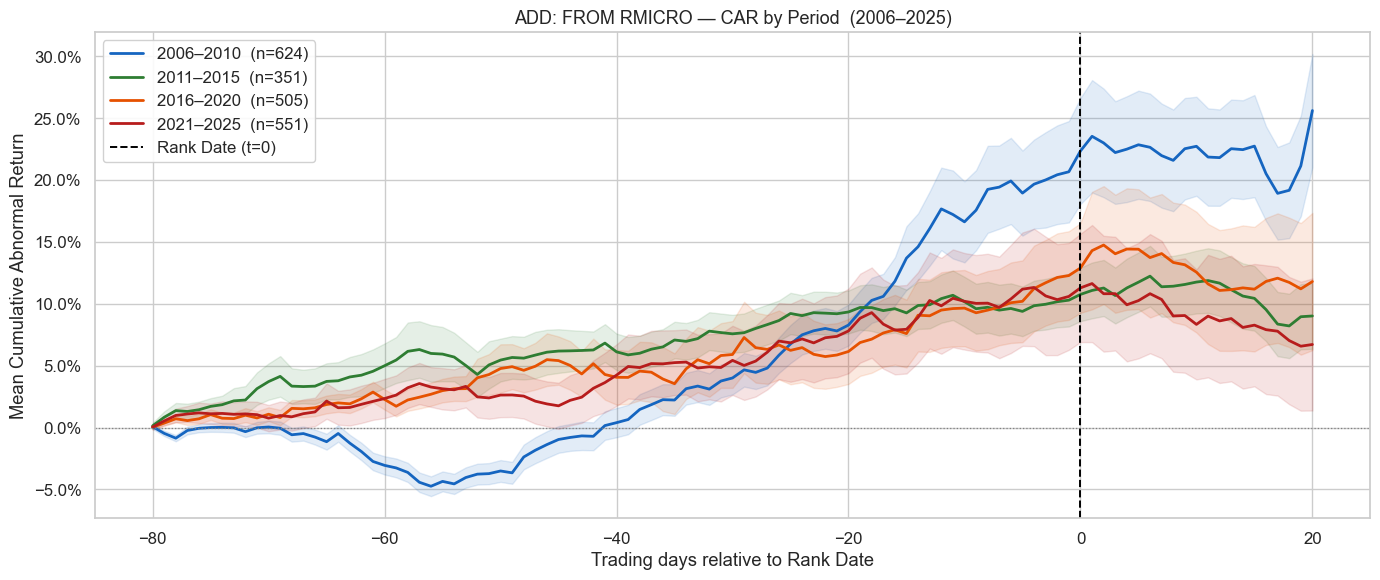

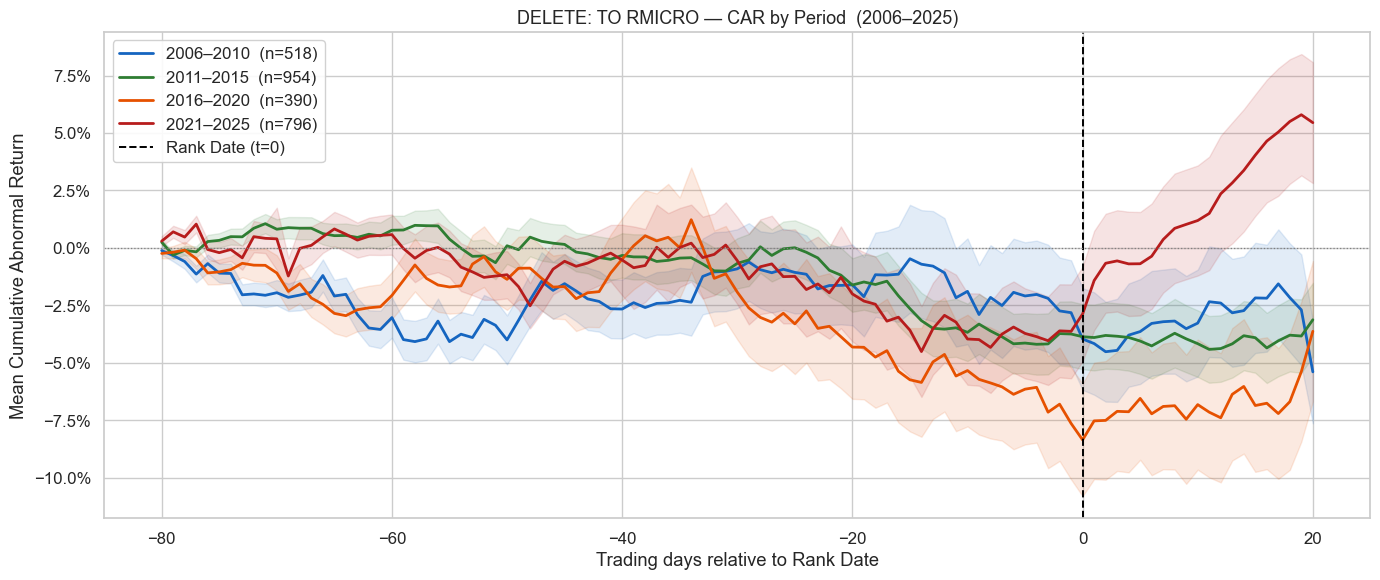

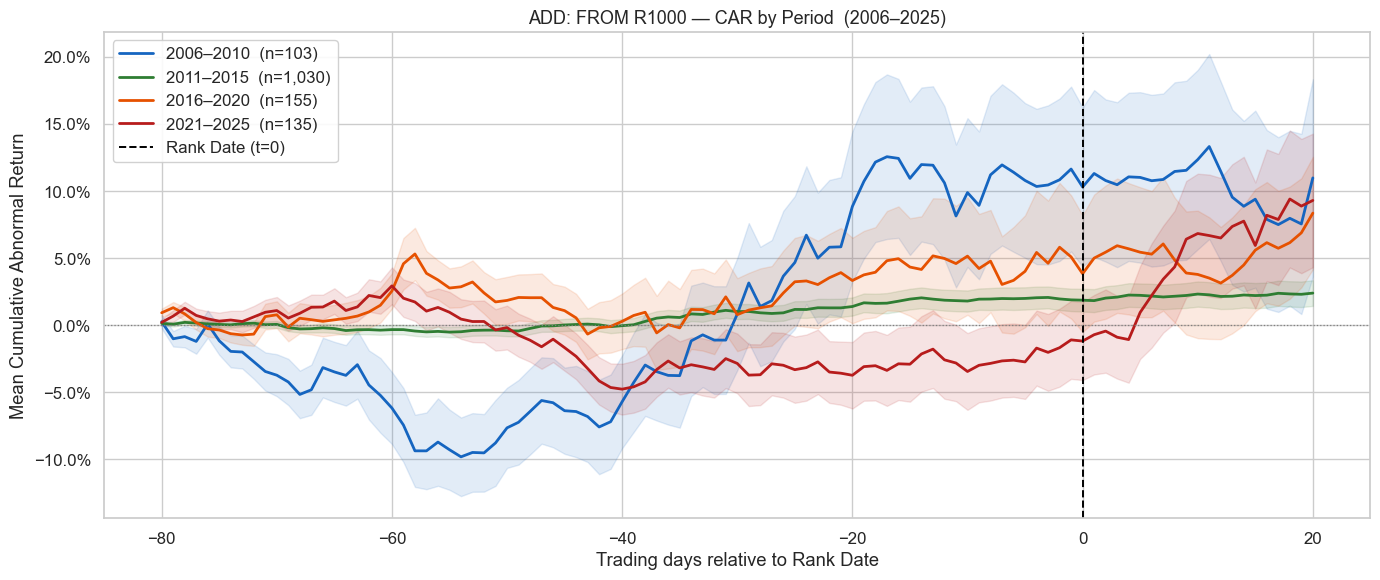

In [8]:
for grp_name, period_results in results_by_period.items():
    fig, ax = plt.subplots(figsize=(14, 6))

    for color, (label, yr_start, yr_end) in zip(PERIOD_COLORS, PERIODS):
        car_df = period_results[label]
        if car_df.empty:
            continue
        mean_car = car_df.mean()
        se       = car_df.std(ddof=1) / np.sqrt(len(car_df))
        ax.plot(EVENT_DAYS, mean_car,
                label=f'{label}  (n={len(car_df):,})', color=color, lw=2)
        ax.fill_between(EVENT_DAYS, mean_car - se, mean_car + se,
                        alpha=0.12, color=color)

    ax.axvline(0, color='black', linestyle='--', lw=1.4, label='Rank Date (t=0)')
    ax.axhline(0, color='gray',  linestyle=':',  lw=0.9)
    ax.set_xlabel('Trading days relative to Rank Date')
    ax.set_ylabel('Mean Cumulative Abnormal Return')
    ax.set_title(f'{grp_name} — CAR by Period  (2006–2025)', fontsize=13)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    ax.legend(framealpha=0.9)
    plt.tight_layout()
    plt.show()

## 8. Grid Plot — 3 Groups × 4 Periods (12 Subplots)

Rows = groups, columns = periods. Significance shading: coloured = |t| ≥ 1.65.

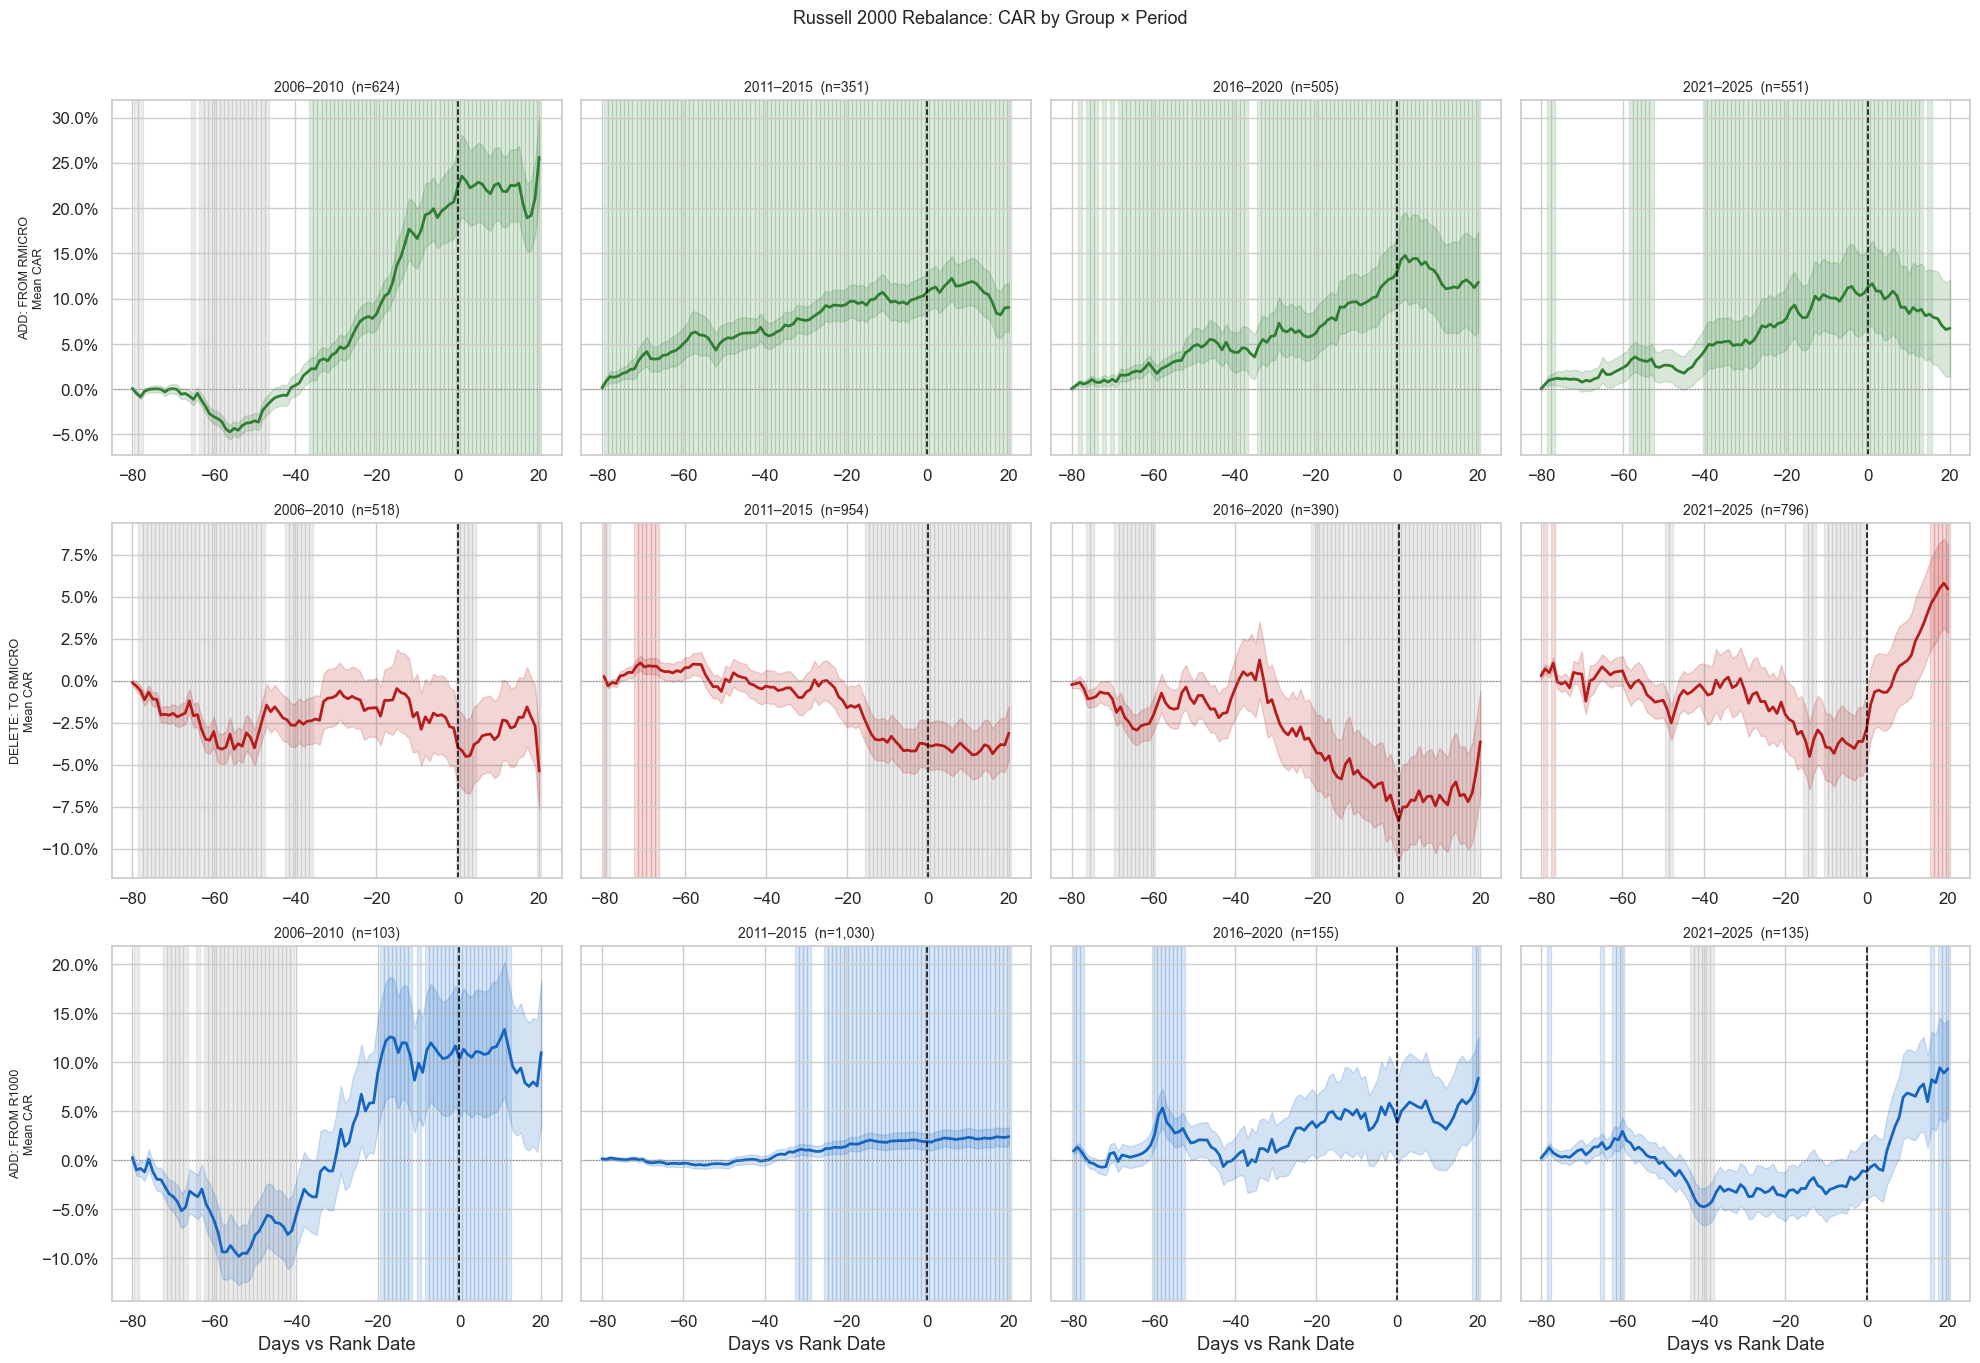

In [9]:
TCRIT = 1.65

GROUP_COLORS = {
    'ADD: FROM RMICRO':  '#2E7D32',
    'DELETE: TO RMICRO': '#B71C1C',
    'ADD: FROM R1000':   '#1565C0',
}

n_groups  = len(FOCUS)
n_periods = len(PERIODS)

fig, axes = plt.subplots(n_groups, n_periods,
                         figsize=(5 * n_periods, 4.5 * n_groups),
                         sharey='row')

for row_idx, (grp_name, period_results) in enumerate(results_by_period.items()):
    color = GROUP_COLORS[grp_name]
    for col_idx, (label, yr_start, yr_end) in enumerate(PERIODS):
        ax     = axes[row_idx, col_idx]
        car_df = period_results[label]

        if car_df.empty:
            ax.set_title(f'{label}\n(no data)')
            continue

        mean_car = car_df.mean()
        se       = car_df.std(ddof=1) / np.sqrt(len(car_df))
        tstat    = mean_car / se.replace(0, np.nan)

        for d in EVENT_DAYS:
            if tstat[d] >=  TCRIT:
                ax.axvspan(d - 0.5, d + 0.5, alpha=0.15, color=color, zorder=0)
            elif tstat[d] <= -TCRIT:
                ax.axvspan(d - 0.5, d + 0.5, alpha=0.15, color='gray', zorder=0)

        ax.plot(EVENT_DAYS, mean_car, color=color, lw=2)
        ax.fill_between(EVENT_DAYS, mean_car - se, mean_car + se,
                        alpha=0.18, color=color)
        ax.axvline(0, color='black', linestyle='--', lw=1.1)
        ax.axhline(0, color='gray',  linestyle=':',  lw=0.8)
        ax.set_title(f'{label}  (n={len(car_df):,})', fontsize=10)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))

        if col_idx == 0:
            ax.set_ylabel(f'{grp_name}\nMean CAR', fontsize=9)
        if row_idx == n_groups - 1:
            ax.set_xlabel('Days vs Rank Date')

plt.suptitle('Russell 2000 Rebalance: CAR by Group × Period', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 9. Summary Table — Key Days by Group × Period

In [10]:
KEY_DAYS = [-20, -10, -1, 0, 5, 10, 20]

rows = []
for grp_name, period_results in results_by_period.items():
    for label, *_ in PERIODS:
        car_df = period_results[label]
        if car_df.empty:
            continue
        for d in KEY_DAYS:
            vals = car_df[d]
            mean = vals.mean()
            se   = vals.std(ddof=1) / np.sqrt(len(vals))
            t    = mean / se if se > 0 else np.nan
            rows.append({
                'Group':  grp_name,
                'Period': label,
                'Day':    d,
                'Mean CAR': f'{mean:+.2%}',
                't-stat':   f'{t:+.2f}' if not np.isnan(t) else 'n/a',
                'n':        len(vals),
                'Sig*':     '*' if not np.isnan(t) and abs(t) >= TCRIT else '',
            })

summary = pd.DataFrame(rows)

for grp_name in results_by_period:
    grp_tbl = summary[summary['Group'] == grp_name].pivot(
        index='Day', columns='Period', values=['Mean CAR', 't-stat', 'Sig*']
    )
    print(f'\n=== {grp_name} ===')
    display(grp_tbl)

print('* |t| ≥ 1.65  (one-sided 10%)')


=== ADD: FROM RMICRO ===


Mean CAR                                  t-stat                      \
Period 2006–2010 2011–2015 2016–2020 2021–2025 2006–2010 2011–2015 2016–2020   
Day                                                                            
-20       +8.28%    +9.34%    +6.15%    +7.81%     +4.99     +5.38     +2.34   
-10      +16.62%   +10.17%    +9.66%   +10.20%     +5.07     +5.07     +3.14   
-1       +20.67%   +10.30%   +12.29%   +10.60%     +5.04     +4.83     +3.43   
 0       +22.35%   +10.76%   +12.89%   +11.29%     +5.21     +4.99     +3.56   
 5       +22.85%   +11.75%   +14.41%   +10.26%     +5.23     +4.90     +2.98   
 10      +22.73%   +11.76%   +12.56%    +8.34%     +5.68     +4.63     +2.57   
 20      +25.62%    +9.02%   +11.80%    +6.71%     +5.61     +3.40     +2.13   

                      Sig*                                
Period 2021–2025 2006–2010 2011–2015 2016–2020 2021–2025  
Day                                                       
-20        +2.28         *         *         *         *  
-10        +2.62         *         *         *         *  
-1         +2.45         *         *         *         *  
 0         +2.58         *         *         *         *  
 5         +2.20         *         *         *         *  
 10        +1.87         *         *         *         *  
 20        +1.26         *         *         *


=== DELETE: TO RMICRO ===


Mean CAR                                  t-stat                      \
Period 2006–2010 2011–2015 2016–2020 2021–2025 2006–2010 2011–2015 2016–2020   
Day                                                                            
-20       -1.61%    -1.62%    -4.32%    -2.00%     -0.91     -1.39     -1.92   
-10       -1.89%    -3.68%    -5.34%    -3.97%     -0.82     -2.94     -2.20   
-1        -2.82%    -3.75%    -7.64%    -3.63%     -1.24     -2.64     -3.14   
 0        -3.97%    -3.87%    -8.36%    -2.88%     -1.79     -2.73     -3.41   
 5        -3.64%    -4.06%    -6.55%    -0.69%     -1.60     -2.83     -2.45   
 10       -3.28%    -4.17%    -6.82%    +1.19%     -1.41     -2.88     -2.41   
 20       -5.40%    -3.13%    -3.63%    +5.45%     -2.41     -1.95     -1.19   

                      Sig*                                
Period 2021–2025 2006–2010 2011–2015 2016–2020 2021–2025  
Day                                                       
-20        -0.97                             *            
-10        -1.99                   *         *         *  
-1         -1.78                   *         *         *  
 0         -1.40         *         *         *            
 5         -0.31                   *         *            
 10        +0.50                   *         *            
 20        +2.07         *         *                   *


=== ADD: FROM R1000 ===


Mean CAR                                  t-stat                      \
Period 2006–2010 2011–2015 2016–2020 2021–2025 2006–2010 2011–2015 2016–2020   
Day                                                                            
-20       +8.86%    +1.39%    +3.33%    -3.73%     +1.58     +2.06     +1.05   
-10       +9.89%    +1.80%    +5.15%    -3.45%     +1.78     +2.28     +1.18   
-1       +11.65%    +1.89%    +5.10%    -1.09%     +1.89     +2.26     +1.11   
 0       +10.31%    +1.87%    +3.84%    -1.18%     +1.74     +2.19     +0.88   
 5       +11.02%    +2.23%    +5.44%    +0.96%     +1.73     +2.52     +1.12   
 10      +12.35%    +2.32%    +3.79%    +6.84%     +1.85     +2.46     +0.80   
 20      +10.99%    +2.40%    +8.36%    +9.31%     +1.49     +2.51     +1.99   

                      Sig*                                
Period 2021–2025 2006–2010 2011–2015 2016–2020 2021–2025  
Day                                                       
-20        -1.51                   *                      
-10        -1.21         *         *                      
-1         -0.38         *         *                      
 0         -0.41         *         *                      
 5         +0.28         *         *                      
 10        +1.53         *         *                      
 20        +1.87                   *         *         *

* |t| ≥ 1.65  (one-sided 10%)
